In [12]:
nums = [2,2,4]
new = []
for i in range(len(nums)-1):
    if nums[i-1] == nums[i]:
        break
    l = nums[i]
    r = nums[i+1]
    if l == r:
        s = l+r
        new.append(s)
    else:
        new.append(l)
print(new)


[4]


In [1]:
from keras import backend as K
from keras import Input
from keras.models import Model
from keras.layers import (
    Dense,
    RNN,
    Layer,
    TimeDistributed,
    SimpleRNN,
    Concatenate,
    Activation,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
)
from keras.regularizers import l2
from keras.callbacks import ModelCheckpoint

import keras
import tensorflow as tf

from tqdm import trange
import tqdm
import numpy as np
import cv2
import pickle
import random
from random import shuffle
import matplotlib.pyplot as plt

In [2]:
f = "splined_trajectories_expanded.txt" # contain 498 trajectories - 0 to 299 - 10, 300 to 498 - 01 - [Lx, Ly, Rx, Ry, Tx, Ty] 

with open(f, "rb") as fp:   #Pickling
        trajectories = np.array(pickle.load(fp))

inp = trajectories[:,:25,:]
out = trajectories[:,1:,:4]
num_inputs = len(inp)
hand_signal = np.zeros((num_inputs,25,2),dtype=int)
hand_signal[:num_inputs//2,:,0] = 1
hand_signal[num_inputs//2:,:,1] = 1

def shuffle_XY(x,y,h):
    x,y,h = list(x),list(y),list(h)
    x_sh,y_sh,h_sh = [],[],[]

    ind = list(range(len(y)))
    shuffle(ind)
   
    for i in ind:
        x_sh.append(x[i])
        y_sh.append(y[i])
        h_sh.append(h[i])
   
    x_sh = np.array(x_sh)
    y_sh = np.array(y_sh)
    h_sh = np.array(h_sh)
   
    return x_sh,y_sh,h_sh

shuffled_inp, shuffled_out, shuffled_hand_signal = shuffle_XY(inp, out, hand_signal)


In [4]:
def feedforward_mlp(input_dim, output_dim=1):
    x_in = Input(shape=(input_dim,), name="input")

    x = Dense(128, activation="relu", name="dense_1")(x_in)
    x = Dense(64,  activation="relu", name="dense_2")(x)
    x = Dense(32,  activation="relu", name="dense_3")(x)

    y_out = Dense(output_dim, name="output")(x)

    return Model(x_in, y_out, name="ff_mlp")

def autoregressive_mlp(input_dim, output_dim):
    x_t = Input(shape=(input_dim,), name="x_t")
    y_prev = Input(shape=(output_dim,), name="y_prev")

    h = Concatenate(name="concat")([x_t, y_prev])
    h = Dense(128, activation="relu", name="dense_1")(h)
    h = Dense(64, activation="relu", name="dense_2")(h)
    h = Dense(32, activation="relu", name="dense_3")(h)

    y_t = Dense(output_dim, name="y_t")(h)

    return Model([x_t, y_prev], y_t, name="autoregressive_mlp")

In [5]:
input_dim = 8       # number of input features
output_dim = 4      # regression output

model = autoregressive_mlp(input_dim, output_dim)

optimizer = tf.keras.optimizers.Adam(1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()

@tf.function
def train_step(X_seq, Y_seq):
    """
    X_seq: (N, T, input_dim)
    Y_seq: (N, T, output_dim)
    """

    N = tf.shape(X_seq)[0]
    T = tf.shape(X_seq)[1]

    # initial previous output y[-1]
    y_prev = tf.zeros((N, output_dim),dtype=Y_seq.dtype)

    total_loss = 0.0

    with tf.GradientTape() as tape:
        for t in tf.range(T):
            y_pred = model([X_seq[:, t, :], y_prev],training=True)

            loss = loss_fn(Y_seq[:, t, :], y_pred)
            total_loss += loss

            # teacher forcing
            y_prev = Y_seq[:, t, :]

        total_loss /= tf.cast(T, tf.float32)

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return total_loss

@tf.function
def val_step(X_seq, Y_seq):
    """
    X_seq: (N, T, input_dim)
    Y_seq: (N, T, output_dim)
    """

    N = tf.shape(X_seq)[0]
    T = tf.shape(X_seq)[1]

    # initial previous output y[-1]
    y_prev = tf.zeros(
        (N, output_dim),
        dtype=Y_seq.dtype
    )

    total_loss = 0.0

    for t in tf.range(T):
        y_pred = model(
            [X_seq[:, t, :], y_prev],
            training=False
        )

        loss = loss_fn(Y_seq[:, t, :], y_pred)
        total_loss += loss

        # teacher forcing
        y_prev = Y_seq[:, t, :]

    total_loss /= tf.cast(T, Y_seq.dtype)
    return total_loss


In [6]:
val_perc = 0.8
val_split = int(val_perc*num_inputs)

X_train = np.concatenate((shuffled_inp[:val_split,:,:],shuffled_hand_signal[:val_split,:,:]),axis=2)
Y_train = shuffled_out[:val_split,:,:]

X_train = X_train.astype("float32")
Y_train = Y_train.astype("float32")

X_val = np.concatenate((shuffled_inp[val_split:,:,:],shuffled_hand_signal[val_split:,:,:]),axis=2)
Y_val = shuffled_out[val_split:,:,:]

X_val = X_val.astype("float32")
Y_val = Y_val.astype("float32")

epochs = 500

pbar = trange(epochs, desc="Training",
            mininterval=0.5,   # seconds between redraws
            smoothing=0.0)      # disables EMA smoothing that causes jitter)
train_loss_history = []
val_loss_history = []
for epoch in pbar:
    train_loss = train_step(X_train, Y_train)
    val_loss   = val_step(X_val, Y_val)
    # print(f"Epoch: {epoch} | Train Loss: {train_loss} | Val Loss: {val_loss}")
    # show losses in the tqdm bar instead of print spam
    # tqdm.write(
    #     f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
    # )
    pbar.set_postfix(
        train_loss=f"{train_loss:.6f}",
        val_loss=f"{val_loss:.6f}",
        refresh = False
    )
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)



Training: 100%|██████████| 500/500 [00:16<00:00, 30.64it/s, train_loss=0.000006, val_loss=0.000006]


Text(0, 0.5, 'Value of Loss')

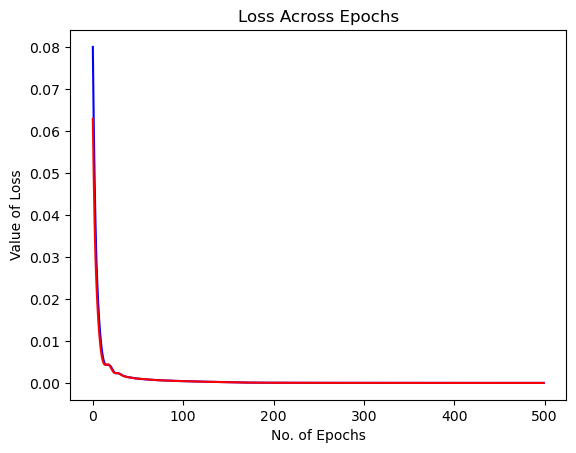

In [7]:
plt.figure()
plt.plot(np.arange(0,epochs),np.array(train_loss_history),color='blue',label='Train Loss')
plt.plot(np.arange(0,epochs),np.array(val_loss_history),color='red',label='Validation Loss')
plt.title("Loss Across Epochs")
plt.xlabel("No. of Epochs")
plt.ylabel("Value of Loss")

In [8]:
model.save("dynamic_model_autoregressive_mlp_v1.keras")